## Encoder を 15 レイヤー用意し，時系列的に入力するモデルの検証


### Import


In [2]:
import python.util as util
from pathlib import Path
import importlib
from typing import Dict
# from transformers import RobertaForSequenceClassification
import torch
from datasets import Dataset
import pandas as pd
import numpy as np
import yaml
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from sklearn.decomposition import PCA
import os
import random


### DEFINE PATH


In [3]:
BASE_PATH = Path.cwd().parent
DATA_PATH = BASE_PATH / "data"
MODEL_PATH = BASE_PATH / "model"
print(f"BASE_PATH: {BASE_PATH}")
print(f"DATA_PATH: {DATA_PATH}")
print(f"MODEL_PATH: {MODEL_PATH}")

BASE_PATH: /home/masa1357/Dockerdata/gitfile/15-Encoders
DATA_PATH: /home/masa1357/Dockerdata/gitfile/15-Encoders/data
MODEL_PATH: /home/masa1357/Dockerdata/gitfile/15-Encoders/model


### Set Seed & Set Logger


In [4]:
importlib.reload(util)
# ? logger読み込み
name = "15-Ensemble"
logger = util.set_logger()
# ? seed値固定
seed = 42
util.set_seed(seed)

2024-10-08 12:54:45,303 : python.util : INFO : 34 : Test_message


In [5]:
# ? データ読み込み
import python.data_manager as dm

importlib.reload(dm)
# argsでloggerの名前を送る

args: Dict[str, object] = {
    "logger": logger,
    "DATA_PATH": DATA_PATH,
    "key": "userid",
    "text": "answer_content",
    "label": "grade",
    "mode": "all",
    "split_rate": [0.8, 0.2, 0],
    "seed": seed,
}

with util.timer("load data"):
    dp = dm.DataProcessing(args)
    df = dp()

2024-10-08 12:54:45,314 : python.util.python.data_manager : INFO : 16 : setup Child logger : python.data_manager
2024-10-08 12:54:45,315 : python.util.python.data_manager : INFO : 65 : Read /home/masa1357/Dockerdata/gitfile/15-Encoders/data/Reflection *.csv data...
2024-10-08 12:54:45,316 : python.util.python.data_manager : INFO : 67 : Found files: [PosixPath('/home/masa1357/Dockerdata/gitfile/15-Encoders/data/Reflection/Course_C-2021-2_Reflection.csv'), PosixPath('/home/masa1357/Dockerdata/gitfile/15-Encoders/data/Reflection/Course_C-2022-1_Reflection.csv'), PosixPath('/home/masa1357/Dockerdata/gitfile/15-Encoders/data/Reflection/Course_C-2021-1_Reflection.csv')]
2024-10-08 12:54:45,393 : python.util.python.data_manager : INFO : 74 : Total rows: 28275
2024-10-08 12:54:45,394 : python.util.python.data_manager : INFO : 65 : Read /home/masa1357/Dockerdata/gitfile/15-Encoders/data/Grade *.csv data...
2024-10-08 12:54:45,395 : python.util.python.data_manager : INFO : 67 : Found files: [Pos

[load data] start
[load data] done in 0.77 s


In [6]:
df.head(3)

,userid,grade,text,course_number,question_number,label
0,C-2021-1_U1,F,情報伝達には声モルス信号など様々な形があり人類の進化と共により高度に精度が高められてきた,01,1,4
1,C-2021-1_U10,B,高校時代で習った情報だけでは現代の進化についていけない\r\n情報はどんな形であっても〇と●...,01,1,1
2,C-2021-1_U100,C,情報の発展の仕方\r\n授業の参加の仕方,01,1,2


### 各生徒の回答を時系列でグループ化


In [7]:
# 質問番号でフィルタ
filter = "1"
Qfilter_df = dm.encode(df, logger=logger, filter=filter)
Qfilter_df.head(3)

/home/masa1357/Dockerdata/gitfile/15-Encoders/src/python/data_manager.py:280: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "new_column"] = df.apply(create_column_name, axis=1)


new_column,userid,label,01-1,02-1,03-1,04-1,05-1,06-1,07-1,08-1,09-1,10-1,11-1,12-1,13-1,14-1,15-1
0,C-2021-1_U1,4,情報伝達には声モルス信号など様々な形があり人類の進化と共により高度に精度が高められてきた,情報源符号化とは情報を黒と白の○で表すことで複合とは符号化によって得られたものを元に戻す作業...,生起確率pの事象の生起を知ったことによる曖昧さの減少量は情報量と一致し生起確率pが高いほど情...,通信の際に符号の誤りを検出・訂正する仕組みについて学んだ符号の誤りは符号語同士がs+1以上離...,コンピュタサイエンスは計算機科学であるともされ全ての科学技術分野の基盤となりうるものであるコ...,計算ステップ数とはアルゴリズムが終了するまでに行われる演算の数である最大公約数の問題では剰余...,マジソトとは入力数列を分割していき分割したものを整列して統合(マジ)するアルゴリズムであるヒ...,[NA],[NA],[NA],[NA],[NA],[NA],[NA],[NA]
1,C-2021-1_U10,1,高校時代で習った情報だけでは現代の進化についていけない\r\n情報はどんな形であっても〇と●...,どのように情報を短く表現するか\r\n符号をを一意に素早く戻すためにはどのような符号にすればよいか,情報の量を表すためにはどのようにすればよいか\r\n2つの現象が起こった場合相互の情報量はど...,誤りの自動検出と自動訂正が可能なハミング距離\r\n符号化効率とブロック誤り率,基礎科学としてのコンピュタサイエンス\r\nコンピュタサイエンスにおける計算と問題とは何か\...,色々なソトの種類とその計算時間量や比較回数\r\n,マジソトと2分探索法\r\n比較ベスのソトアルゴリズムのまとめ,デタとは何か\r\nデタの予測発見分類・グルピング\r\n,人工知能(AI)特化型AIとは何か\r\n身の回りの人工知能\r\n人工知能の機械学習\r\...,非構造化デタの処理\r\nパタン認識とは何か\r\nパタン認識と機械学習,デタ収集とバイアス\r\n個人情報とデタ\r\nオプンデタについて,ベクトルによるデタ表現ベクトルとは何か\r\nベクトルとデタ分析の関係\r\n距離や類似度と...,デタの可視化とは\r\n色々な可視化方法\r\n多次元デタの可視化,相関デタの広がりと分散\r\n統計的検定とは何か\r\n画像処理と解析(フィルタ処理),期末テスト\r\n授業アンケト
2,C-2021-1_U100,2,情報の発展の仕方\r\n授業の参加の仕方,情報源符号化によって情報が伝えられるときより軽く瞬時に伝わるような仕組み,エントロピ情報量について,通信路符号化ビット反転によってノイズが生じる仕組み自動訂正自動検出について,計算とアルゴリズムについて効率のよい計算,いろいろなソトについて,マジソト2分探索法について,デタについて,AIについての基礎情報,非構造デタとはパタン認識とは,デタの収集にはどのような方法があるのか調査方法バイアスとは個人情報について,ベクトルについていろいろな距離についてデタにおける類似とは,デタの可視化について,デタの間の関係性相関統計的検定について画像解析フィルタ処理について,期末テスト


In [29]:
import pandas as pd
import numpy as np
from gensim.models import KeyedVectors
from transformers import RobertaTokenizer, RobertaModel
import torch
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer
import MeCab  # MeCabをインポート

def compute_similarity(df,tokenizer, roberta_model,column,
                       word2vec_model_path = '/home/masa1357/Dockerdata/gitfile/Tree-Model/model/word2vec_testcase.model'
                       ):
    # word2vecモデルのロード
    word2vec_model = KeyedVectors.load(word2vec_model_path)
    
    # RoBERTaのトークナイザとモデルのロード
    roberta_model_name = 'nlp-waseda/roberta-base-japanese'
    tokenizer = AutoTokenizer.from_pretrained("nlp-waseda/roberta-base-japanese")
    roberta_model = RobertaModel.from_pretrained(roberta_model_name)
    
      # MeCabの初期化
    mecab = MeCab.Tagger('-Owakati')  # 単語分割のみを行うオプション
    
    # RoBERTaのベクトルを格納するリスト（PCAの学習用）
    roberta_vectors = []
    
    # データフレームのインデックスをリセット（後で使用）
    df = df.reset_index(drop=True)
    
    # --- RoBERTaのベクトル取得 ---
    for idx, text in enumerate(df[column]):
        inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=512)
        with torch.no_grad():
            outputs = roberta_model(**inputs)
        roberta_sentence_vector = outputs.last_hidden_state[0,0,:].numpy()
        roberta_vectors.append(roberta_sentence_vector)
    
    # RoBERTaベクトルをPCAでword2vecの次元数に縮小
    n_components = word2vec_model.vector_size  # word2vecの次元数に合わせる
    pca = PCA(n_components=n_components)
    roberta_vectors_pca = pca.fit_transform(roberta_vectors)
    
    similarities = []

    for idx, text in enumerate(df[column]):
        # --- word2vecのベクトル取得 ---
        # MeCabによる単語分割
        words = mecab.parse(text).strip().split()
        word_vectors = []
        for word in words:
            if word in word2vec_model.wv:
                word_vectors.append(word2vec_model.wv[word])
        if len(word_vectors) == 0:
            word2vec_sentence_vector = np.zeros(word2vec_model.vector_size)
        else:
            word2vec_sentence_vector = np.mean(word_vectors, axis=0)
        
        # --- RoBERTaのベクトル取得（PCA適用済み） ---
        roberta_sentence_vector_pca = roberta_vectors_pca[idx]
        
        # --- 類似度の計算 ---
        similarity = cosine_similarity(
            [word2vec_sentence_vector],
            [roberta_sentence_vector_pca]
        )[0][0]
        
        similarities.append(similarity)
    
    df['result'] = similarities
    
    return df
# 使用例
# df = pd.DataFrame({'text': ["これはテスト文章です。", "もう一つの文章です。"]})
# df = compute_similarity(df, 'path_to_word2vec_model')
# print(df)


In [30]:
with open("./config/Encoder_Architecture.yaml") as file:
    EncoderModelConfig = yaml.safe_load(file)
    logger.info(EncoderModelConfig)
# RobertaconfigにEncoderModelConfigをつなげる
# -> すでにある設定は上書き，ない設定は追加
from transformers import RobertaConfig
# YAMLの辞書を使ってRobertaConfigを一括設定
config_dict = EncoderModelConfig['RobertaConfig']
config_dict['num_labels'] = EncoderModelConfig['num_class']  # num_classを追加
#! config_dict['is_15layers] == Trueの場合，num_hidden_layersをdatasetの2次元めの列数に変更
if config_dict['is_15layers']:
    config_dict['num_hidden_layers'] = 14
    print(f"num_hidden_layers: {config_dict['num_hidden_layers']}")
# layer_norm_epsをfloatに変換
if 'layer_norm_eps' in config_dict:
    config_dict['layer_norm_eps'] = float(config_dict['layer_norm_eps'])
config = RobertaConfig.from_dict(config_dict)  # 辞書から設定

2024-10-08 13:01:44,876 : python.util : INFO : 3 : {'num_class': 5, 'RobertaConfig': {'architectures': ['RobertaForSequenceClassification'], 'attention_probs_dropout_prob': 0.1, 'bos_token_id': 2, 'classifier_dropout': None, 'eos_token_id': 3, 'hidden_act': 'gelu', 'hidden_dropout_prob': 0.1, 'hidden_size': 768, 'initializer_range': 0.02, 'intermediate_size': 3072, 'layer_norm_eps': '1e-12', 'max_position_embeddings': 514, 'model_type': 'roberta', 'num_attention_heads': 12, 'num_hidden_layers': 14, 'pad_token_id': 0, 'position_embedding_type': 'absolute', 'torch_dtype': 'float32', 'transformers_version': '4.38.1', 'type_vocab_size': 2, 'use_cache': True, 'vocab_size': 32000, 'is_decoder': True, 'log': True, 'log_path': '/home/masa1357/Dockerdata/gitfile/15-Encoders/src/log/15layers', 'is_15layers': True, 'add_cross_attention': True, 'is_check_state': False}}


num_hidden_layers: 14


In [31]:
from transformers import RobertaTokenizer
from transformers import AutoTokenizer
import python.Roberta_15layers
importlib.reload(python.Roberta_15layers)
from python.Roberta_15layers import RobertaFor15LayersClassification
tokenizer = AutoTokenizer.from_pretrained("nlp-waseda/roberta-base-japanese")
checkpoint_path = "/home/masa1357/Dockerdata/gitfile/15-Encoders/model/roberta_base_japanese_finetuned/checkpoint-100"
model = RobertaFor15LayersClassification.from_pretrained(checkpoint_path, config=config)


2.4.1+cu121


log is in config


In [36]:
result = compute_similarity(Qfilter_df,tokenizer, model, "01-1")

Some weights of RobertaModel were not initialized from the model checkpoint at nlp-waseda/roberta-base-japanese and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [38]:
result.columns

Index(['userid', 'label', '01-1', '02-1', '03-1', '04-1', '05-1', '06-1',
       '07-1', '08-1', '09-1', '10-1', '11-1', '12-1', '13-1', '14-1', '15-1',
       'result'],
      dtype='object', name='new_column')

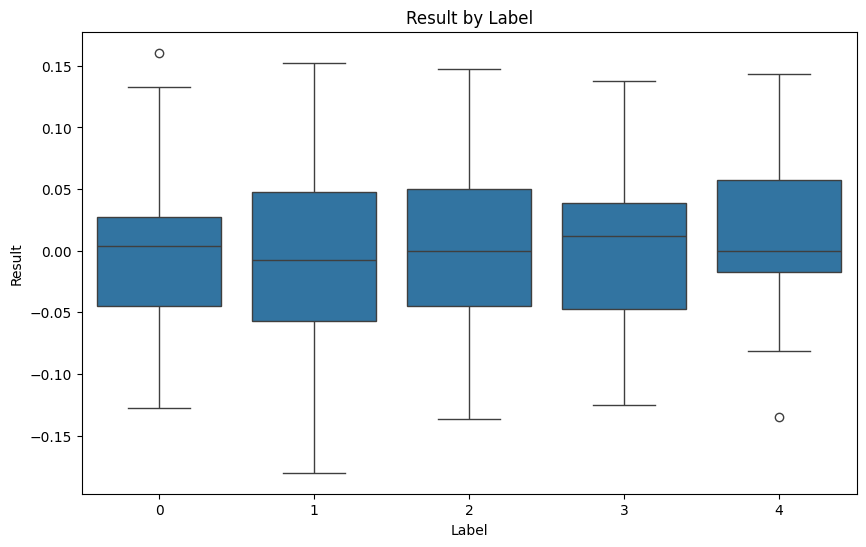

In [39]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='result', data=result)
plt.title('Result by Label')
plt.xlabel('Label')
plt.ylabel('Result')
plt.show()